# Text Classification with DistilBERT (AG News)


## Install Libraries

In [1]:
import transformers
import datasets
import huggingface_hub

print(transformers.__version__)
print(datasets.__version__)
print(huggingface_hub.__version__)

4.55.0
3.6.0
0.34.4


In [2]:
#!pip uninstall -y torchvision
#!pip install torchvision==0.22.1

In [3]:
!pip install -q transformers datasets accelerate evaluate

## Import Libraries

In [4]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

## Load Dataset

In [5]:
from datasets import load_dataset

raw_datasets = load_dataset("ag_news")

raw_datasets

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

## Explore Dataset

In [6]:
label_names = raw_datasets["train"].features["label"].names
num_labels = len(label_names)
print(label_names)

df_train = raw_datasets["train"].to_pandas()
df_test = raw_datasets["test"].to_pandas()
print(df_train.shape, df_test.shape)
df_train.head()


['World', 'Sports', 'Business', 'Sci/Tech']
(120000, 2) (7600, 2)


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [7]:
df_train["label"].value_counts().sort_index()


,count
label,
0,30000
1,30000
2,30000
3,30000


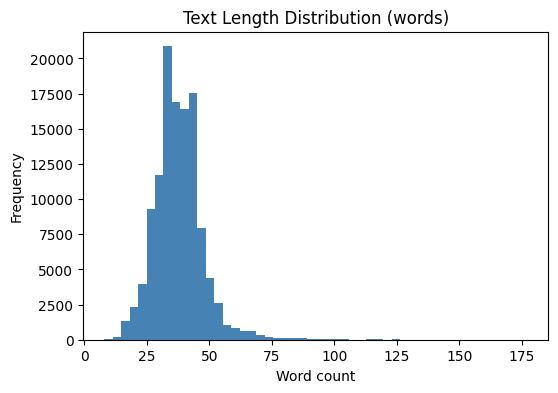

In [8]:
df_train["text_len"] = df_train["text"].str.split().apply(len)

plt.figure(figsize=(6, 4))
plt.hist(df_train["text_len"], bins=50, color="steelblue")
plt.title("Text Length Distribution (words)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

df_train = df_train.drop(columns=["text_len"])


## Data Preprocessing

In [9]:
def clean_df(df):
    df = df.dropna(subset=["text", "label"]).copy()
    df["text"] = df["text"].str.strip()
    df = df[df["text"].str.len() > 0]
    return df.reset_index(drop=True)

df_train = clean_df(df_train)
df_test = clean_df(df_test)

print("Missing values:\n", df_train.isnull().sum())


Missing values:
 text     0
label    0
dtype: int64


In [10]:
# Subsample for a Colab-friendly training time, keeping class balance
N_TRAIN_PER_CLASS = 2000
N_TEST_PER_CLASS = 500

df_train = (
    df_train.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=N_TRAIN_PER_CLASS, random_state=SEED))
    .reset_index(drop=True)
)
df_test = (
    df_test.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=N_TEST_PER_CLASS, random_state=SEED))
    .reset_index(drop=True)
)

df_train.shape, df_test.shape


/tmp/ipykernel_9265/858121691.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=N_TRAIN_PER_CLASS, random_state=SEED))
/tmp/ipykernel_9265/858121691.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=N_TEST_PER_CLASS, random_state=SEED))


((8000, 2), (2000, 2))

## Tokenization

In [11]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

tokenizer(df_train["text"].iloc[0], truncation=True, max_length=MAX_LENGTH)


{'input_ids': [101, 7738, 5749, 13952, 5101, 13952, 1010, 5712, 1010, 2257, 2484, 1011, 1011, 1037, 2482, 5968, 9913, 2379, 1996, 4796, 1997, 1037, 2149, 1011, 6787, 8956, 2547, 2897, 1999, 13952, 2006, 9857, 1010, 4288, 2012, 2560, 2048, 2111, 1998, 27285, 2048, 2500, 1010, 4614, 1998, 9390, 2056, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

## Train Test Split

In [12]:
train_val_ds = Dataset.from_pandas(df_train[["text", "label"]], preserve_index=False)
test_ds = Dataset.from_pandas(df_test[["text", "label"]], preserve_index=False)

split = train_val_ds.train_test_split(
    test_size=0.2,
    seed=SEED,
    shuffle=True
)

dataset_dict = DatasetDict({
    "train": split["train"],
    "validation": split["test"],
    "test": test_ds,
})
dataset_dict


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [13]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_datasets


Map:   0%|          | 0/6400 [00:00<?, ? examples/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 6400
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1600
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## Baseline Model

In [14]:
X_train_text = dataset_dict["train"]["text"]
y_train = dataset_dict["train"]["label"]
X_test_text = dataset_dict["test"]["text"]
y_test = dataset_dict["test"]["label"]

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

baseline_clf = LogisticRegression(max_iter=1000, random_state=SEED)
baseline_clf.fit(X_train_tfidf, y_train)

baseline_preds = baseline_clf.predict(X_test_tfidf)


Logistic Regression (TF-IDF) -> Accuracy: 0.8835 | Precision: 0.8832 | Recall: 0.8835 | F1: 0.8832
              precision    recall  f1-score   support

       World       0.90      0.88      0.89       500
      Sports       0.92      0.95      0.94       500
    Business       0.85      0.84      0.85       500
    Sci/Tech       0.86      0.86      0.86       500

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000



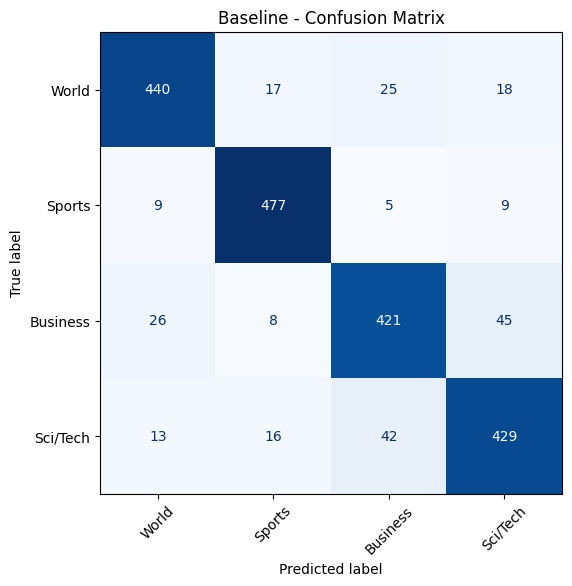

In [15]:
def evaluate_predictions(y_true, y_pred, label_names, title="Model"):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    print(f"{title} -> Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_names))
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

def plot_confusion_matrix(y_true, y_pred, label_names, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap=cmap, xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.show()

baseline_metrics = evaluate_predictions(y_test, baseline_preds, label_names, title="Logistic Regression (TF-IDF)")
plot_confusion_matrix(y_test, baseline_preds, label_names, "Baseline - Confusion Matrix", cmap="Blues")


## Fine-Tuning DistilBERT

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
model.to(DEVICE)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_strategy="epoch",
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.547200,0.288938,0.907500,0.908695,0.907500,0.907581
2,0.222300,0.291325,0.911875,0.911690,0.911875,0.911709
3,0.145700,0.297324,0.910625,0.910639,0.910625,0.910385


## Model Evaluation

In [19]:
test_metrics_trainer = trainer.evaluate(tokenized_datasets["test"])
test_metrics_trainer


{'eval_loss': 0.2878436744213104,
 'eval_accuracy': 0.9125,
 'eval_precision': 0.9136196406754713,
 'eval_recall': 0.9125,
 'eval_f1': 0.9127626347252016,
 'eval_runtime': 2.2594,
 'eval_samples_per_second': 885.202,
 'eval_steps_per_second': 27.884,
 'epoch': 3.0}

DistilBERT (fine-tuned) -> Accuracy: 0.9125 | Precision: 0.9136 | Recall: 0.9125 | F1: 0.9128
              precision    recall  f1-score   support

       World       0.94      0.91      0.92       500
      Sports       0.97      0.98      0.98       500
    Business       0.84      0.88      0.86       500
    Sci/Tech       0.90      0.88      0.89       500

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



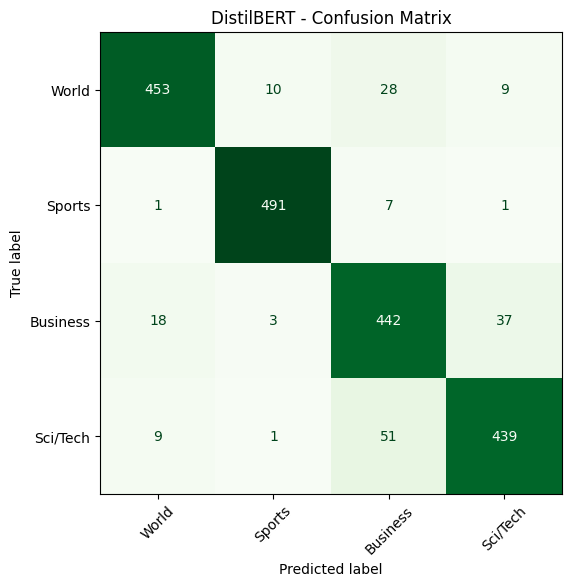

In [20]:
predictions = trainer.predict(tokenized_datasets["test"])
y_pred_transformer = np.argmax(predictions.predictions, axis=-1)
y_true_transformer = predictions.label_ids

transformer_metrics = evaluate_predictions(
    y_true_transformer, y_pred_transformer, label_names, title="DistilBERT (fine-tuned)"
)
plot_confusion_matrix(
    y_true_transformer, y_pred_transformer, label_names, "DistilBERT - Confusion Matrix", cmap="Greens"
)


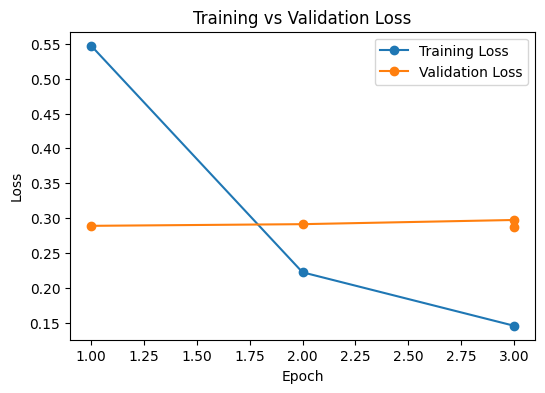

In [21]:
log_history = trainer.state.log_history
train_loss = [(x["epoch"], x["loss"]) for x in log_history if "loss" in x]
eval_loss = [(x["epoch"], x["eval_loss"]) for x in log_history if "eval_loss" in x]

epochs_train, losses_train = zip(*train_loss)
epochs_eval, losses_eval = zip(*eval_loss)

plt.figure(figsize=(6, 4))
plt.plot(epochs_train, losses_train, marker="o", label="Training Loss")
plt.plot(epochs_eval, losses_eval, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


## Performance Comparison

In [22]:
comparison_df = pd.DataFrame([
    {"Model": "Logistic Regression (TF-IDF)", **baseline_metrics},
    {"Model": "DistilBERT (fine-tuned)", **transformer_metrics},
])
comparison_df


,Model,accuracy,precision,recall,f1
0,Logistic Regression (TF-IDF),0.8835,0.883183,0.8835,0.883225
1,DistilBERT (fine-tuned),0.9125,0.913620,0.9125,0.912763


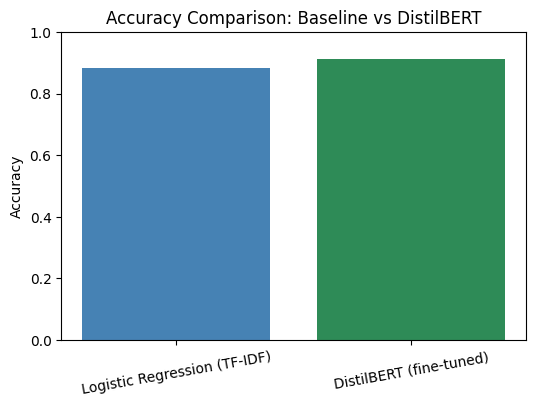

In [23]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df["Model"], comparison_df["accuracy"], color=["steelblue", "seagreen"])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: Baseline vs DistilBERT")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.show()


## Inference

In [24]:
def predict_texts(texts, model, tokenizer, label_names, device=DEVICE):
    model.eval()
    inputs = tokenizer(texts, return_tensors="pt", truncation=True, padding=True, max_length=MAX_LENGTH)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    preds = torch.argmax(logits, dim=-1).cpu().numpy()
    return [label_names[p] for p in preds]

sample_texts = [
    "The stock market rallied today after strong earnings reports from major banks.",
    "The national team secured a dramatic victory in the final minutes of the match.",
    "Scientists have developed a new battery technology that could double smartphone life.",
    "Diplomats met this week to discuss the ongoing border dispute between the two nations.",
]

for text, pred in zip(sample_texts, predict_texts(sample_texts, model, tokenizer, label_names)):
    print(f"[{pred}] {text}")


[Business] The stock market rallied today after strong earnings reports from major banks.
[Sports] The national team secured a dramatic victory in the final minutes of the match.
[Sci/Tech] Scientists have developed a new battery technology that could double smartphone life.
[World] Diplomats met this week to discuss the ongoing border dispute between the two nations.


## Save Model

In [25]:
SAVE_DIR = "./distilbert-ag-news"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)


('./distilbert-ag-news/tokenizer_config.json',
 './distilbert-ag-news/special_tokens_map.json',
 './distilbert-ag-news/vocab.txt',
 './distilbert-ag-news/added_tokens.json',
 './distilbert-ag-news/tokenizer.json')

In [26]:
reloaded_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
reloaded_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)

for text, pred in zip(sample_texts, predict_texts(sample_texts, reloaded_model, reloaded_tokenizer, label_names)):
    print(f"[{pred}] {text}")


[Business] The stock market rallied today after strong earnings reports from major banks.
[Sports] The national team secured a dramatic victory in the final minutes of the match.
[Sci/Tech] Scientists have developed a new battery technology that could double smartphone life.
[World] Diplomats met this week to discuss the ongoing border dispute between the two nations.
